# Creating SEV, NPS, OF
_Author: Àfrica González Pedraza, Danaé Valdenaire_<br>
_Created: May 19th, 2026_<br>
_Last updated: June 25th, 2026 by Danaé Valdenaire_

---

This tutorial will teach you how to: 
- Apply quality cuts
- Create the Standard Event (SEV), which is the typical pulse shape of your signal in the detector
- Generate the Noise Power Spectrum (NPS), which describes the typical noise frequencies found in your noise
- Build the Optimum Filter (OF), which is a frequency filter that detects typical signal frequencies and suppresses noise
- Calculate the baseline resolution of the detector

The exact workflow for building these objects is a matter of preference. We present two main approaches but you can customize the workflow or combine the two methods.

In [ ]:
import os
import numpy as np
import cait as ai
import cait.versatile as vai
import scipy as sp

## First, you need (mock) data

Before starting the work, we need to create our [`DataHandler`](cait.DataHandler) that contains our data. If you are not familiar with `DataHandler`, I really advice you to have a look at the `triggering tutorial`. All the steps from the creation to the DataHandler to the triggering of the stream data are well described there. 

In [ ]:
# Generate mockdata

fdirh5 = "tutorial_output"
hdf5_name = "my_first_trigger"
os.makedirs(fdirh5, exist_ok=True)

record_length = 2**14

trigger_config = {
    "trigger_channels": ["Ch0"],
    "passive_channels": ["Ch1"],
    "testpulse_channels": ["TP0", "TP1"],
    "controlpulses_above": [9., 9.],
    "f_noise": 1000,
    "copy_events": True,
}
n_channels = len(trigger_config["trigger_channels"]) + len(trigger_config["passive_channels"])

stream = vai.MockStream(seed=137, rate_Hz=2)

In [ ]:
# Above, we already accessed some of the data that was stored in the DataHandler using
# the [] notation. To see all the available groups/datasets, you can run
dh.content()

## Load DataHandler

In [ ]:
fdirh5 = "tutorial_output"
hdf5_name = "my_first_trigger"
os.makedirs(fdirh5, exist_ok=True)

record_length = 2**14

trigger_config = {
    "trigger_channels": ["Ch0"],
    "passive_channels": ["Ch1"],
    "testpulse_channels": ["TP0", "TP1"],
    "controlpulses_above": [9., 9.],
    "f_noise": 1000,
    "copy_events": True,
}
n_channels = len(trigger_config["trigger_channels"]) + len(trigger_config["passive_channels"])

# Set the path to the desired HDF5 file
dh = ai.DataHandler(record_length=record_length, 
                    nmbr_channels=n_channels, 
                    sample_frequency=stream.sample_frequency)

dh.set_filepath(path_h5="tutorial_output", fname="my_first_trigger", appendix=False)

# 2. Quality cuts, SEV cuts and SEV creation

**For beginners: data cleaning**

- The first step of the data analysis is to perform a stability cut of the data. This means: discard artifacts 
(such as flux quantum losses, SQUID resets, voltage spikes, ...) via *quality cuts*, and discarding events recorded while the detector temperature was unstable.

This means: All events --> Reject unstable time periods --> reject artifacts/apply quality cuts --> clean events 

- The second step is to create the Standard Event (SEV) by selecting high-quality events that exhibit the typical pulse shapes of the 
signal. These events will later be averaged and fitted. The averaged pulse shape is the SEV.

That means: Clean events --> Apply strict SEV cuts --> SEV events --> Average --> SEV 

For the SEV cut event selection, start with the events surviving the stability cuts and then perform *strict* cuts by analyzing 
each parameter. Here, the number of events surviving the cuts is less relevant. The most important aspect is that the remaining events:

1) Only contain one pulse (no pile-ups),
2) Are in the linear region (no saturated events),
3) Start and end in a flat baseline (i.e. discard events starting from a falling baseline)
4) Have very similar onset values (prevent the SEV from washing out during the averaging process).

## Quality and SEV Cuts

The exact workflow for building those objects is a matter of preference. We present the two main approaches but of you can individualize the workflow and/or combine the two methods.

**Method 1: ``VizTool``:** Creates interactive 2D and 3D plots to visualize any parameter stored in the DataHandler and included in ``datasets``.
The function allows you to select events directly in the plots and visualize their individual shapes. By changing the group, you can also visualize testpulses and 
noise. The event selection can be later rejected, included in the DataHandler or averaged to identify the mean pulse shape.

**Method 2: ``Cait.versatile``:** Creates individual 2D and 3D plots, where the event selection occurs with logical expressions. The visualization of the 
selected events is done separately.

For beginners, Method 1 is more practical for getting to know the data and learing how different types of pulses are distributed in the 2D plots. 

**Advantages** of Method 1 compared to Method 2: 
- Faster identification and selection of populations
- Faster saving of the selection to the DataHandler
- Faster visualization of the mean pulse shape
- Ideal for beginners to explore and play around with the data and pulse shape characteristics

**Disadvantages** of Method 1 compared to Method 2:
- Lower precision: Events are selected manually by hand, whereas Method 2 uses precise, logical expresssions.
- Less traceability: the boundaries of the cuts and cut parameters are not saved orvisible, whereas Method 2 hardcodes the cut limits and parameters, providing a clear overview.
- Can be slower if a large number fo cuts are performed 
- Large amount of data must be downsampled; otherwise, the VizTool performance drops significantly. 

## Method 1 - Using `cait.VizTool`: Interactive plotting

1) Select x and y value to be plotted. 

Guidelines for beginners:

    - x-axis: Events are typically plotted against the pulse height (first approximation of the energy). In some cases, it is also useful to plot against time to identify if a certain feature is equally distributed throughout the measurement or concentrated in a specific time period. 
    - y-axis: Try experimenting with all the parameters. Observe how the distributions change and how different populations arise in the different parameters (see Tips below)
    - Density plots: prevent overplotting in large datasets by using continuous shading to reveal the true concentration and patterns of data where a scatter plot would just show a solid, unreadable blob of dots.
    - Color axis: Use a third parameter as a color axis to discover the interplay between the parameters.

2) In the top right corner, click 'Box Select'. Select the region on the graph that contains the events you want to study. 
3) Below the plot, check how many events you have selected, and scroll through the events to recognize their characteristics.

   3.1) **Storing a selection (flag):**  If you want to store a flag containing the events of the selectied region in the DataHandler, type your desired name for the selection in the tect box, press ``Enter``, and click 'Save Selected'. Saved cuts: 
    - are stored even if the cell is recompiled,
    - can be individually analyzed/plotted later,
    - can be overwritten by using the same name.

    Example: If you are only interested in events with a decay time parameter of 3.1 ms, select those events, type in the box 'decay_time_cut', press ``Enter``, and click 'Save Selected'.
   
   Tipp 1: I recommend to save the events that survive each cut to keep track of the cut process and to analyze them individually later. Otherwise, individual cuts will not be preserved.
   
   Tipp 2: Give each cut descriptive name. I recommend keeping record (on paper or markdown cell) of what each cut does (e.g., decay_time_cut selects events with a decay time of 3.1ms). 

   3.2) **Cutting out a region:** To remove a region from the current view, click 'Cut Selected' (only once!). This removes the events from the ``VizTool`` interface but does not alter anything in the DataHander. 
   - Warning: Once events are removed from the view, they cannot be recovered without starting over or reloading from a previously saved cut.
   - Clicking "Cut Selected" more than once will remove all remaining events from the VizTool.
   - To start over from the beginning, re-execute the viz = ... cell.
   - To reload a previously saved cut and/or to downsample the data, uncomment the corresponding 
   lines below.

   3.3) **Calculating the average pulse shape:** Click 'Calc SEV' and then observe the event visualization window. This tool is only for visualization (does not store anything in the DataHandler) and should always be used to ensure the SEV does not feature distortions. If the shape looks clean, scroll through the selected events to verify there are no hidden artifacts and then save the cut as 'sev_cut' (following the steps in 3.1).

   3.4) Create a SEV cut for each channel individually.


### Tips for beginners:

- Understand the parameters. How does each parameter describe which part/feature of the pulse? See how the parameters are defined in the section "Parameter Definitions" at the end of this jupyter notebook or [in the cait documentation](https://cait.readthedocs.io/en/latest/magic.html).
- **Explore the data:** Once you know how each parameter is calculated, play around with the plots and select different regions of the spectrum. This will help you to get familiar with how specific types of pulses correspond to certain parameter values.
- **Choose relevant parameters based on the pulse features you want to discard:**
  For example: To isolate SQUID resets (characterized by a step-like jump of O(~8 V)), the pulse height (maximum of the trace after a moving average) or the slope (mean of the last fifty samples minus the mean of the first fifty samples) are highly effective parameters for discriminating SQUID resets from true signal events. Always try to find the specific parameters that best capture the unique characteristics of the events you wish to reject. There is no unique combination of parameters ofr the cuts; different parameter sets can yield the same result, and each dataset will require its own tailored cuts. 



In [ ]:
ch = 0 #channel number, change accordingly
datasets = {
    'Time (h)': ['hours', None, None],
    'Pulse Height Phonon (V)': ['pulse_height', ch, None],
    'Rise Time Phonon (ms)': ['rise_time', ch, None],
    'Decay Time Phonon (ms)': ['decay_time', ch, None],
    'Onset Phonon (ms)': ['onset', ch, None],
    'Slope Phonon (V)': ['baseline_slope', ch, None],
    'Variance Phonon (V^2)': ['variance', ch, None],
}

#  Add to the datasets the parameters you want to visualize. 
# dh.content() to see which parameter are available.

In [ ]:
#viz.set_idx(np.nonzero(dh.get('events', 'decay_time_cut'))[1])                      ## Visualize a preselected cut
#viz.set_idx(np.arange(0, n_events, downsample_factor))                                       ## Downsample events or noise
#viz.set_idx(np.random.choice(n_testpulses, n_testpulses//downsample_factor, replace=False))  ## Downsample testpulses randomly
# viz.set_idx(np.nonzero(dh.get('events', 'some_cut'))[1])[::downsample_factor]      ## Downsample a preselected cut

In [ ]:
viz = ai.VizTool(datahandler = dh,
                 group='events', #or group='testpulses', group='noise'...
                 datasets=datasets,
                 bins = 100,
                )            
viz.show()

In [ ]:
quality_cuts_viztool = ai.cuts.LogicalCut()

ph_cut = (dh["events/pulse_height",0]>=-0.1)*(dh["events/pulse_height",0]<=2)
slope_cut = (dh["events/baseline_difference",0]<2)*(dh["events/baseline_difference",0]>-2)
cut_variance = dh["events/variance",0]<0.01
cut_decay_time = (dh["events/decay_time",0]<35)*(dh["events/decay_time",0]>20)

quality_cuts_viztool.add_condition(ph_cut*slope_cut*cut_variance*cut_decay_time)

Even when using VizTool, don't forget to save your cuts. It's crucial for the reproductibility of your analysis. The best way is to store them directly in your DataHandler $\downarrow$

In [ ]:
dh.apply_logical_cut(cut_flag=quality_cuts_viztool.get_flag(),  
                     naming='quality_cuts_viztool',
                     channel=0,
                     type='events',
                     delete_old=True)

## Method 2 -  Using `cait.versatile`: Histograms and logical expressions

`cait.versatile` offers various plotting function to visualise your data in an interactive way. For more information about the plotting functions available, click [here](https://cait.readthedocs.io/en/develop/documentation/versatile/plotting.html).

In [ ]:
vai.Scatter(y=dh["testpulses/pulse_height",0], x=dh["testpulses/timestamps",0], xlabel='Test pulse timestamps', ylabel='Pulse height (V)')

In [ ]:
vai.Scatter(y=dh["testpulses/testpulseamplitude",0], x=dh["testpulses/pulse_height",0], xlabel='Test pulse timestamps', ylabel='Pulse height (V)')

In [ ]:
vai.Histogram(dh["events/pulse_height",0], bins=(0.02,0.05,300),xlabel='Pulse height (V)')

In [ ]:
vai.Histogram(dh["events/onset",0], bins=(-10,10,300), xlabel='Onset (V)')

In [ ]:
vai.Histogram(dh["events/decay_time",0], bins=(200),xlabel='Rise time (ms)')

After refining the value of your cuts, you can save them as follow $\downarrow$ 

In [ ]:
quality_cuts = ai.cuts.LogicalCut()
quality_cuts.add_condition((dh["events/onset", 0]>-0.8)*(dh["events/onset", 0]<-0.4)); print(quality_cuts.counts())
quality_cuts.add_condition((dh["events/decay_time", 0]<40)); print(quality_cuts.counts())
quality_cuts.add_condition((dh["events/pulse_height", 0]>0.1)); print(quality_cuts.counts())

In [ ]:
print('Survived: {}/{}, {:.2f} %'.format(quality_cuts.counts(), quality_cuts.total(), 100*quality_cuts.counts()/quality_cuts.total()))

```{tip}
To see all functionnalities available with LogicalCut(), you can write press `TAB` after writing `quality_cuts.`
```

Then, you might want to see how the remaining events look like.

In [ ]:
# Visualize the events that survive your cuts

vai.Preview(
    dh.get_event_iterator("events", channel=0, flag=quality_cuts.get_flag()).with_processing(
        vai.RemoveBaseline()
    )
)

Looking at the events, it looks like there is no artefacts remaining (all pulses look like particle events). However, there is a few pile-up still in our data. Usually, pile-up are easily removed with the parametric fit since those events will have a higher fit rms. We can then move on to the next step save the quality cuts in the DataHandler. 

In [ ]:
dh.apply_logical_cut(cut_flag=quality_cuts.get_flag(),                                                             
                     naming='quality_cuts',
                     channel=0,
                     type='events',
                     delete_old=True)

You should see now the quality cuts in the event group $\downarrow$ 

In [ ]:
dh.content("events")

```{tip}
If you made a mistake or your not happy with the selection, you can do `dh.drop("group", "subgroup")` and start over. 
```

## Creating a SEV for particle events

A standard event is a template that should describe the shape of your pulses in the linear regime of your detector. To create it, we need to select the best-looking pulses we have in our dataset and then average them. It's pretty easy to do with `cait`, we just have to follow the steps we just described. First we define our quality cuts, then we apply them on the event group and when we are happy with how it looks, we save the [SEV object](cait.versatile.analysisobjects.sev).

First, we need the iterator containing our clean events.

In [ ]:
#Load quality_cuts from dh

quality_cuts = dh["events/quality_cuts",0]

In [ ]:
event_iterator = dh.get_event_iterator(group="events", channel=0, flag=quality_cuts)

We can already define a SEV by averaging those events as a first draft.

In [ ]:
sev = vai.SEV(event_iterator)

Then, we can run the template fit a first time to use the rms of the fit to filter the remaining "bad events".

In [ ]:
fitpar, _, rms = vai.apply(vai.TemplateFit(sev, bl_poly_order=1), event_iterator)

We can use the function `ScatterPreview` to plot the rms of the fit. This function allows you to display the event corresponding to each point of the scatter plot.

In [ ]:
vai.ScatterPreview(rms, np.arange(len(rms)), event_iterator.with_processing(vai.RemoveBaseline()))

We see that there is multiple population in the rms of the fit. We can then exclude the pile-ups by selecting an upper limit on the rms.

In [ ]:
sev = vai.SEV(event_iterator[:, rms<0.005])

Then we can display the result by doing:

In [ ]:
sev.show()

When you're happy with how the SEV looks, you can save it in your DataHandler! Let's create one in which we will store the SEV, the NPS, OF etc.

In [ ]:
dh_SEV = ai.DataHandler(record_length=record_length, 
                    nmbr_channels=n_channels, 
                    sample_frequency=stream.sample_frequency)

dh_SEV.set_filepath(path_h5="tutorial_output", fname="my_SEV_OF_NPS", appendix=False)
dh_SEV.init_empty()

In [ ]:
sev.to_dh(dh_SEV,"events","stdevent", overwrite_existing=True)

### Fit the sev with a pulse shape model

In [ ]:
# Remove remaining noise by fitting template
fit_slice = slice(int(0.24*len(sev)), int(0.6*len(sev)))
t_for_fit = sev.t[fit_slice]
sev_for_fit = sev[fit_slice]

# Find optimal parameters
pars, _  = sp.optimize.curve_fit(ai.fit.pulse_template, 
                                 t_for_fit, 
                                 sev_for_fit, 
                                 p0=[-1, -0.5, 1.5, 1, 0.1, 10], 
                                 bounds=((-10, -10, -10, 0, 0, 0), (10, 10, 10, np.inf, np.inf, np.inf)))
# Evaluate model using optimal parameters
sev_fit = ai.fit.pulse_template(sev.t, *pars)
scale = np.max(sev_fit)

t, A, T = sev.t, np.zeros_like(sev), np.zeros_like(sev)
cond = t > pars[0]
A[cond] =  pars[1] * (np.exp(-(t[cond] - pars[0]) / pars[3]) - np.exp(-(t[cond] - pars[0]) / pars[4])) / scale
T[cond] =  pars[2] * (np.exp(-(t[cond] - pars[0]) / pars[5]) - np.exp(-(t[cond] - pars[0]) / pars[3])) / scale

# Plot result
vai.Line({
    "SEV for events": [t, sev], 
    f"Fit\ntau_n={pars[-3]:.2f} ms\ntau_in={pars[-2]:.2f} ms\ntau_t={pars[-1]:.2f} ms": [t, sev_fit],
    "Athermal component": [t, A],
    "Thermal component": [t, T],
},
    xlabel="Time (ms)",
);

In [ ]:
dh_SEV.set("events", stdevent_pars=pars, stdevent_fit=sev_fit, overwrite_existing=True)

## Creating a SEV for testpulses

As for the event template, the testpulse template has to be build in the linear region of the detector. Practically, it means that you have to select one of the first `testpulseamplitude` value to create your template. We can just add it in the list of the quality cuts.

In [ ]:
# Check all the parameters we have for the testpulses

dh.content("test*")

In [ ]:
# Check all the testpulse ampltiude available

np.unique(dh["testpulses/testpulseamplitude", 0])

In [ ]:
quality_cuts_TP = ai.cuts.LogicalCut()
quality_cuts_TP.add_condition((dh["testpulses/testpulseamplitude", 0]==1)); print(quality_cuts_TP.counts())

In [ ]:
dh.apply_logical_cut(cut_flag=quality_cuts_TP.get_flag(),                                                             
                     naming='quality_cuts_TP',
                     channel=0,
                     type='testpulses',
                     delete_old=True)

In [ ]:
quality_cuts_TP = dh["testpulses/quality_cuts_TP",0]
event_iterator = dh.get_event_iterator(group="testpulses", channel=0, flag=quality_cuts_TP)

In [ ]:
sev = vai.SEV(event_iterator)

In [ ]:
fitpar, _, rms = vai.apply(vai.TemplateFit(sev, bl_poly_order=1), event_iterator)

In [ ]:
vai.ScatterPreview(rms, np.arange(len(rms)), event_iterator.with_processing(vai.RemoveBaseline()))

In [ ]:
sev = vai.SEV(event_iterator[:, rms<0.00505])

In [ ]:
dh_SEV = ai.DataHandler(record_length=record_length, 
                    nmbr_channels=n_channels, 
                    sample_frequency=stream.sample_frequency)
dh_SEV.set_filepath(path_h5="tutorial_output", fname="my_SEV_OF_NPS", appendix=False)
dh_SEV.init_empty()

In [ ]:
sev.to_dh(dh_SEV,"testpulses","stdevent", overwrite_existing=True)

### Fitting testpulse SEV with a pulse shape model

In [ ]:
# Remove remaining noise by fitting template
fit_slice = slice(int(0.24*len(sev)), int(0.6*len(sev)))
t_for_fit = sev.t[fit_slice]
sev_for_fit = sev[fit_slice]

# Find optimal parameters
pars, _  = sp.optimize.curve_fit(ai.fit.pulse_template, 
                                 t_for_fit, 
                                 sev_for_fit, 
                                 p0=[-1, -0.5, 1.5, 1, 0.1, 10], 
                                 bounds=((-10, -10, -10, 0, 0, 0), (10, 10, 10, np.inf, np.inf, np.inf)))
# Evaluate model using optimal parameters
sev_fit = ai.fit.pulse_template(sev.t, *pars)
scale = np.max(sev_fit)

t, A, T = sev.t, np.zeros_like(sev), np.zeros_like(sev)
cond = t > pars[0]
A[cond] =  pars[1] * (np.exp(-(t[cond] - pars[0]) / pars[3]) - np.exp(-(t[cond] - pars[0]) / pars[4])) / scale
T[cond] =  pars[2] * (np.exp(-(t[cond] - pars[0]) / pars[5]) - np.exp(-(t[cond] - pars[0]) / pars[3])) / scale

# Plot result
vai.Line({
    "SEV for testpulses": [t, sev], 
    f"Fit\ntau_n={pars[-3]:.2f} ms\ntau_in={pars[-2]:.2f} ms\ntau_t={pars[-1]:.2f} ms": [t, sev_fit],
    "Athermal component": [t, A],
    "Thermal component": [t, T],
},
    xlabel="Time (ms)",
);

In [ ]:
dh_SEV.set("testpulses", stdevent_pars=pars, stdevent_fit=sev_fit, overwrite_existing=True)

```{tips}
The pulse shape parameter of your SEVs will be very useful to perform a parametric fit. More info in the `amplitude_reconstruction`tutorial.
```

# 3. NPS, OF and calculation of the baseline resolution

In the following section, we will approximate the Baseline Resolution (BR) using the filtered noise method.

1) Apply a set of cuts to the noise traces to remove those containing events. The traces surviving these cuts are stored in a group called 'noise_cuts'.
2) Create the Noise Power Spectrum (NPS). The NPS decomposes the frequencies encountered in noise traces and their respective amplitudes. To generate the NPS, the cleaned noise traces are transformed into the Fourier space to perform a frequency decomposition. 
3) Combine the NPS and the SEV to build a matched filter called Optimum Filter (OF). The OF identifies signal frequencies and suppresses noise, thereby enhancing the Signal-to-Noise ratio (SNR). 

Typical applications of the OF:
- **Calculate the baseline resolution:** determines the resolution and threshold of the detector (later in this notebook)
- **Pulse amplitude reconstruction:** Enhanced precision for events in the linear range compared to the SEV fit (see ``new_tutorial_amplitude_reconstruction.ipynb`` notebook)
- **Retriggering:** A better SNR allows for a reduced threshold (see ``new_tutorial_trigger.ipynb`` notebook)

4) Apply the OF to "noise_cuts" traces.
5) Plot the OF amplitude at one-fourth (or any fix point) of the record window and fit it with a Gaussian function.
6) The standard deviation of the Gaussian corresponds to the BR.

## Cleaning the noise traces

Noise traces may contain pulses. Clean the noise traces such that they only feature noise by performing the event cuts/selections analogously to those for the SEV (Method 1/ Method 2). 

```{Warning}
   - **Time consistency:** The time cut applied to the noise traces must be identical to the one used for the events, as we only want to analyze the noise present during our active time.
   - **Cut flexibility:** The remaining cuts differ from the event cuts and do not necessarily need to be as strict as those used for selecting SEV events.
- Clean the noise traces for each channel independently.
```


In [ ]:
dh.content("noise")

In [ ]:
# performing quality cuts on noise traces

noise_cuts = ai.cuts.LogicalCut()
noise_cuts.add_condition(abs(dh["noise/pulse_height", 0])<0.01); print("Surviving after cut 1:", noise_cuts.counts())
noise_cuts.add_condition(dh["noise/variance", 0]<2e-6); print("Surviving after cut 2:", noise_cuts.counts())

print('Survived: {}/{}, {:.2f} %'.format(noise_cuts.counts(), noise_cuts.total(), 100*noise_cuts.counts()/noise_cuts.total()))

In [ ]:
# Inspecting quality of baselines

noise_cleaned = dh.get_event_iterator(
    "noise")[0, noise_cuts.get_flag()].with_processing(vai.RemoveBaseline())
    
vai.Preview(noise_cleaned) 

In [ ]:
# Remove everything that has large RMS when fit with cubic baselines

noise_traces = dh.get_event_iterator("noise", channel=0).with_processing(vai.RemoveBaseline())
fit_par, fit_rms = vai.apply(vai.FitBaseline(model=3, where=1.0), noise_traces)  

In [ ]:
vai.ScatterPreview(fit_rms[:,0], np.arange(len(fit_rms)), noise_traces.with_processing(vai.RemoveBaseline()))

In [ ]:
noise_cuts.add_condition(fit_rms[:,0] < 0.00508)

In [ ]:
# Saving the quality cuts

dh.apply_logical_cut(cut_flag=noise_cuts.get_flag(),                                   
                     naming='cuts_for_nps',
                     channel=0,
                     type='noise',
                     delete_old=True)

In [ ]:
dh_SEV = ai.DataHandler(record_length=record_length, 
                    nmbr_channels=n_channels, 
                    sample_frequency=stream.sample_frequency)
dh_SEV.set_filepath(path_h5="tutorial_output", fname="my_SEV_OF_NPS", appendix=False)
dh_SEV.init_empty()

In [ ]:
# Applying all the quality cuts on the noise traces 
noise_quality_cuts = dh["noise/cuts_for_nps",0]
noise_traces = dh.get_event_iterator("noise", channel=0, flag=noise_quality_cuts)

# Store in the dh
nps = vai.NPS(noise_traces)
nps.to_dh(dh_SEV, overwrite_existing=True)

In [ ]:
nps.show()

## Creating optimum filter (OF) by combining SEV and NPS

In [ ]:
sev = vai.SEV().from_dh(dh_SEV, "stdevent") #load SEV from the datahandler, specify the group name if you have multiple SEVs
nps = vai.NPS().from_dh(dh_SEV, "nps")      
vai.OF(sev, nps).to_dh(dh_SEV, overwrite_existing=True)              #create the OF from the NPS and SEV, and store in the datahandler

of = vai.OF().from_dh(dh_SEV, "optimumfilter")      #retrieve OF from the datahandler, specify the group name if you have multiple NPSa

In [ ]:
of.show()

# 4. Baseline resolution (BR)

The energy resolution of a detector quantifies the precision or sharpness with which it can distinguish different deposited energies
from one another. This resolution is generally energy-dependent, whereas the baseline resolution describes the resolution for a zero-energy deposition. 
An event with zero energy deposition will always be reconstructed with a non-zero amplitude,
intrinsically limited/biased by the random fluctuations in the noise. The spread of this noise
yields the minimal precision attainable for the energy reconstruction.

There are different approaches to estimating this value.
Most common mthods (discussed in this notebook):
- **Option 1:** Filter empty noise traces with the OF and calculate the spread of the OF amplitudes evaluated at a fixed position.
- **Option 2:** Simulate events with a given pulse height (ph), calculate the spread of the reconstructed OF amplitudes around the simulated ph.

Other methods (not in this notebook):
- Width of the trigger efficiency function
- ...

## Option 1: BR with filtered noise 

1) Apply the OF to the empty noise traces.
2) Plot the OF amplitudes evaluated at a fixed point of the record window and fit with a Gaussian function. By evaluating the amplitude at a fixed point, we prevent bias arising from the fact that the OF will always find a maximum within a trace, even in the absence of pulses. Consequenlty, we expect a Gaussian distribution centered around zero. In this notebook, we choose the fixed point to be at one-fourth of the record window, which corresponds to where the maximum position would be located if a pulse were present. 
3) The standard deviation of the Gaussian fit corresponds to the BR.

In [ ]:
it_noise = dh.get_event_iterator("noise", 0, dh.get('noise', 'noise_cuts')[0])

# load OF from data handler and select your channel
of = vai.OF().from_dh(dh_SEV)

it_noise.add_processing(vai.OptimumFiltering(of)) # Filter the noise traces with the OF

ind = int(record_length / 4) #1/4 of record window = location of peak = highest signal to noise ratio expected if an event is present in the trace
def pick(event): return event[ind]

vals_noise = vai.apply(pick,it_noise) #evaluate the filtered traces at the ind position


In [ ]:
# Plot distribution

min_fit, max_fit = -5, 5
phs = 1000*vals_noise
fit_x = np.linspace(min_fit, max_fit, 1000)

hist = vai.Histogram(
    phs,
    xlabel="OF amplitude of empty noise traces at a fixed position (mV)", 
    bins=fit_x, 
)

gauss_fitpar = sp.stats.norm.fit(phs[(phs>min_fit)*(phs<max_fit)])
hist.add_line(x=fit_x, 
              y=len(phs[(phs>min_fit)*(phs<max_fit)])*np.diff(fit_x)[0]*sp.stats.norm.pdf(fit_x, *gauss_fitpar), 
              name=f"μ={gauss_fitpar[0]:.3f} mV\nσ={gauss_fitpar[1]:.3f} mV")

The standard deviation of the noise distribution after OF filtering gives the baseline resolution (BR) in volts, which can be converted to eV by multiplying with the calibration factor obtained in the `tutorial on energy calibration`.

## Option 2: BR with simulated events

In [ ]:
noise_events = dh.get_event_iterator("noise", 0, dh.get('noise', 'noise_cuts')[0])
noise_traces_for_sim = noise_events[:, ::2]  # downsample less in case of fewer statistics

simulate_ph = 1 # in V, change according to your data

of = vai.OF().from_dh(dh_SEV, "optimumfilter")
sev = vai.SEV().from_dh(dh_SEV, "stdevent")

# Simulate fixed pulse height on noise traces
sim_events = vai.iterators.PulseSimIterator(
    noise_traces_for_sim, 
    pulse_heights=simulate_ph*np.ones(len(noise_traces_for_sim)),
    sev=sev,
)

# Reconstruct pulse heights
ph_rec = vai.apply(
    vai.OFPulseHeight(of, sev), 
    sim_events.with_batchsize(10)
)[1]

In [ ]:
# Plot distribution

min_fit, max_fit = simulate_ph*0.99, simulate_ph*1.01
phs = ph_rec
fit_x = np.linspace(min_fit, max_fit, ph_rec.shape[0])

hist = vai.Histogram(
    phs,
    xlabel=f"Reconstructed OF PH (mV)", 
    bins=fit_x, 
)

gauss_fitpar = sp.stats.norm.fit(phs[(phs>min_fit)*(phs<max_fit)])

hist.add_line(x=fit_x, 
              y=len(phs[(phs>min_fit)*(phs<max_fit)])*np.diff(fit_x)[0]*sp.stats.norm.pdf(fit_x, *gauss_fitpar), 
              name=f"μ={gauss_fitpar[0]:.5f} mV\nσ={gauss_fitpar[1]:.5f} mV")

# Comments

## Pulse shape types

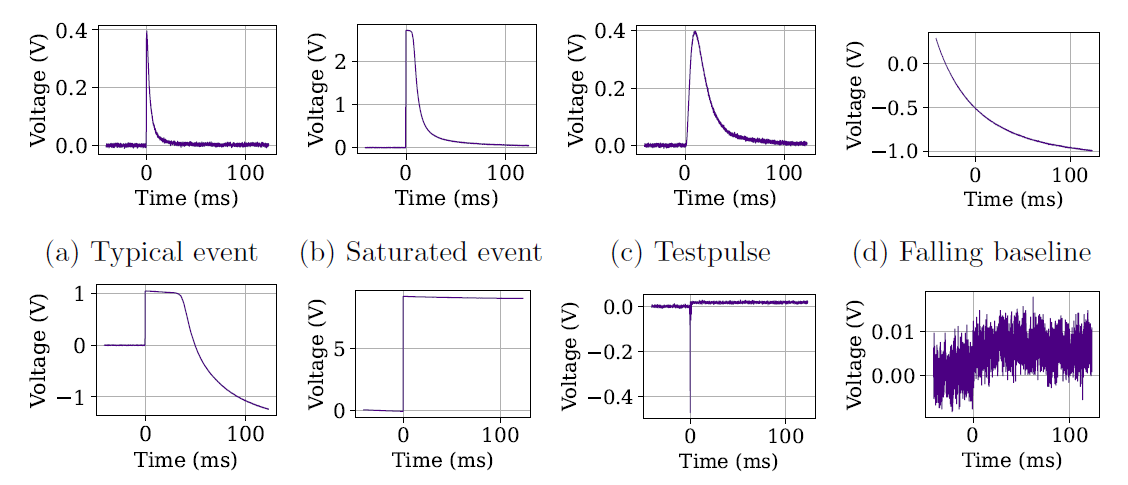

## Parameter definitions

**Offset or baseline level:** Mean of the first fifty samples of the record window (pre-trigger region).

**Pulse height:** Maximum value of the trace after applying a 50-sample moving average filter, after substracting the offset.

**Slope(baseline slope):** The difference between the mean of the first and last fifty samples in the record window.

**Minimum/maximum derivative:** Minimum and maximum values of the first derivative
of the trace. Calculated by the highest positive and negative slope values between
consecutive samples within the record window.

For timing parameters:

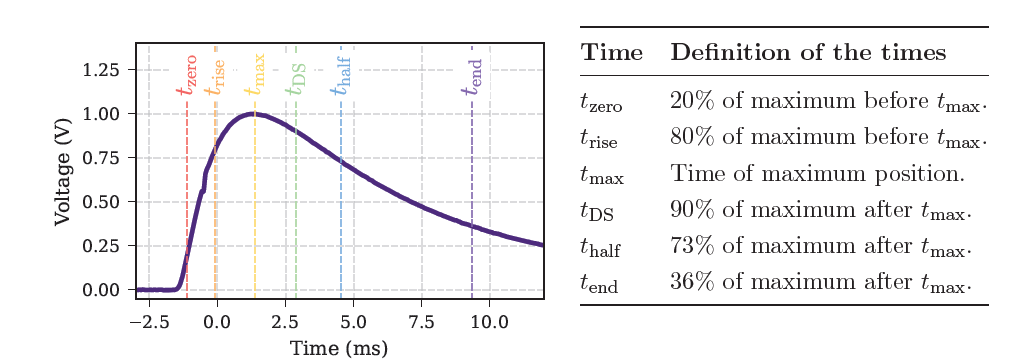

For further parameters consult the cait documentation website.